# H-CAST Current-Run Trade-Off Plots

This notebook mirrors the Hier-COS current-run plots with a smaller run matrix: the native H-CAST baseline, coarse-first explicit lexicographic training, and HCC with `step@0` or `step@80`. It reads the independently selected test checkpoint for every completed seed.

HCC activation is verified from logged `proj_constraint_alpha`, not inferred from directory names. The summary reports both the first active logged epoch and the HCC alpha stored in the independently selected checkpoint's test metrics. A delayed-HCC checkpoint selected before activation is therefore visible as `selected α=0`.

FPA and level accuracy are higher-is-better; TICE is lower-is-better. Points and error bars are mean ± sample standard deviation across training seeds. H-CAST lex runs disable global KL on all datasets, while the Aircraft HCC launcher also uses the no-global-KL arm; deltas from the native baseline therefore are descriptive rather than single-variable effects for those comparisons.

In [6]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

for root in (Path.cwd(), *Path.cwd().parents):
    helper_dir = root / 'analysis' / 'current_runs'
    if (helper_dir / 'current_run_plot_utils.py').is_file():
        sys.path.insert(0, str(helper_dir))
        break
else:
    raise FileNotFoundError('Run this notebook from the repository tree so analysis/current_runs is discoverable.')

from current_run_plot_utils import (
    discover_reference_rows, discover_rows, model_reference_specs,
    plot_fpa_tice, plot_level_accuracy_deltas, print_availability,
    print_reference_availability, print_summary,
)

plt.style.use('seaborn-v0_8-whitegrid')
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
SAVE_FIGURES = False
FIGURE_DIR = OUTPUTS_ROOT / 'analysis' / 'current_runs' / 'hcast'

DATASETS = {
    'cifar100': 'CIFAR-100',
    'cub200': 'CUB-200',
    'aircraft': 'Aircraft',
}

def hcc_run_name(dataset, activation_epoch):
    no_kl_suffix = '_nokl' if dataset == 'aircraft' else ''
    return f'hcast_hcc_{dataset}_step_{activation_epoch}epoch{no_kl_suffix}'

RUN_SPECS = [
    {'key': 'baseline', 'label': 'Baseline', 'family': 'baseline', 'color': '#0072B2', 'marker': 'o', 'hatch': '',
     'run_name': 'hcast_{dataset}'},
    {'key': 'baseline no_kl', 'label': 'Baseline no_kl', 'family': 'baseline', 'color': "#2CE8CC", 'marker': 'o', 'hatch': '',
        'run_name': 'hcast_{dataset}_nokl'},
    {'key': 'lex_coarse_first', 'label': 'Lex coarse-first', 'family': 'lex', 'color': '#D55E00', 'marker': '^', 'hatch': '//',
     'run_name': 'hcast_{dataset}_lex_orthogonalize_all_coarse_first'},
    {'key': 'hcc_step_0', 'label': 'HCC step@0', 'family': 'hcc', 'color': '#009E73', 'marker': 's', 'hatch': '\\',
     'run_name': lambda dataset: hcc_run_name(dataset, 0)},
    {'key': 'hcc_step_80', 'label': 'HCC step@80', 'family': 'hcc', 'color': '#CC79A7', 'marker': 'D', 'hatch': 'xx',
     'run_name': lambda dataset: hcc_run_name(dataset, 80)},
]

REFERENCE_SPECS = model_reference_specs(exclude={'hcast'})


In [7]:
rows, missing_runs = discover_rows(OUTPUTS_ROOT, DATASETS, RUN_SPECS)
reference_rows, missing_reference_runs = discover_reference_rows(OUTPUTS_ROOT, DATASETS, REFERENCE_SPECS)
print_availability(rows, missing_runs, DATASETS)
print_reference_availability(reference_rows, missing_reference_runs, DATASETS)


CIFAR-100
  Baseline                  3 seed(s): hcast_cifar100
  Baseline no_kl            1 seed(s): hcast_cifar100_nokl
  Lex coarse-first          2 seed(s): hcast_cifar100_lex_orthogonalize_all_coarse_first
  HCC step@0                1 seed(s): hcast_hcc_cifar100_step_0epoch
  HCC step@80               1 seed(s): hcast_hcc_cifar100_step_80epoch

CUB-200
  Baseline                  3 seed(s): hcast_cub200
  Baseline no_kl            1 seed(s): hcast_cub200_nokl
  Lex coarse-first          3 seed(s): hcast_cub200_lex_orthogonalize_all_coarse_first
  HCC step@0                1 seed(s): hcast_hcc_cub200_step_0epoch
  HCC step@80               1 seed(s): hcast_hcc_cub200_step_80epoch

Aircraft
  Baseline                  3 seed(s): hcast_aircraft
  Lex coarse-first          3 seed(s): hcast_aircraft_lex_orthogonalize_all_coarse_first
  HCC step@0                1 seed(s): hcast_hcc_aircraft_step_0epoch_nokl
  HCC step@80               1 seed(s): hcast_hcc_aircraft_step_80epoch_nokl


## Independent FPA–TICE Trade-Off

Each panel shows individual seeds, the across-seed mean, a one-standard-deviation covariance ellipse when at least three seeds are available, and collision-aware direct labels. Higher FPA and lower TICE are preferred.

Other model baselines use the same off-scale representation as the Hier-COS notebook. The axis range is frozen on H-CAST runs alone. A contextual model outside that range is pinned into a shaded gutter; its triangle tip points toward the true value, while the label reports the actual FPA and TICE. A square marks an in-range reference. These models are context rather than controlled comparisons and are excluded from H-CAST Pareto analysis.

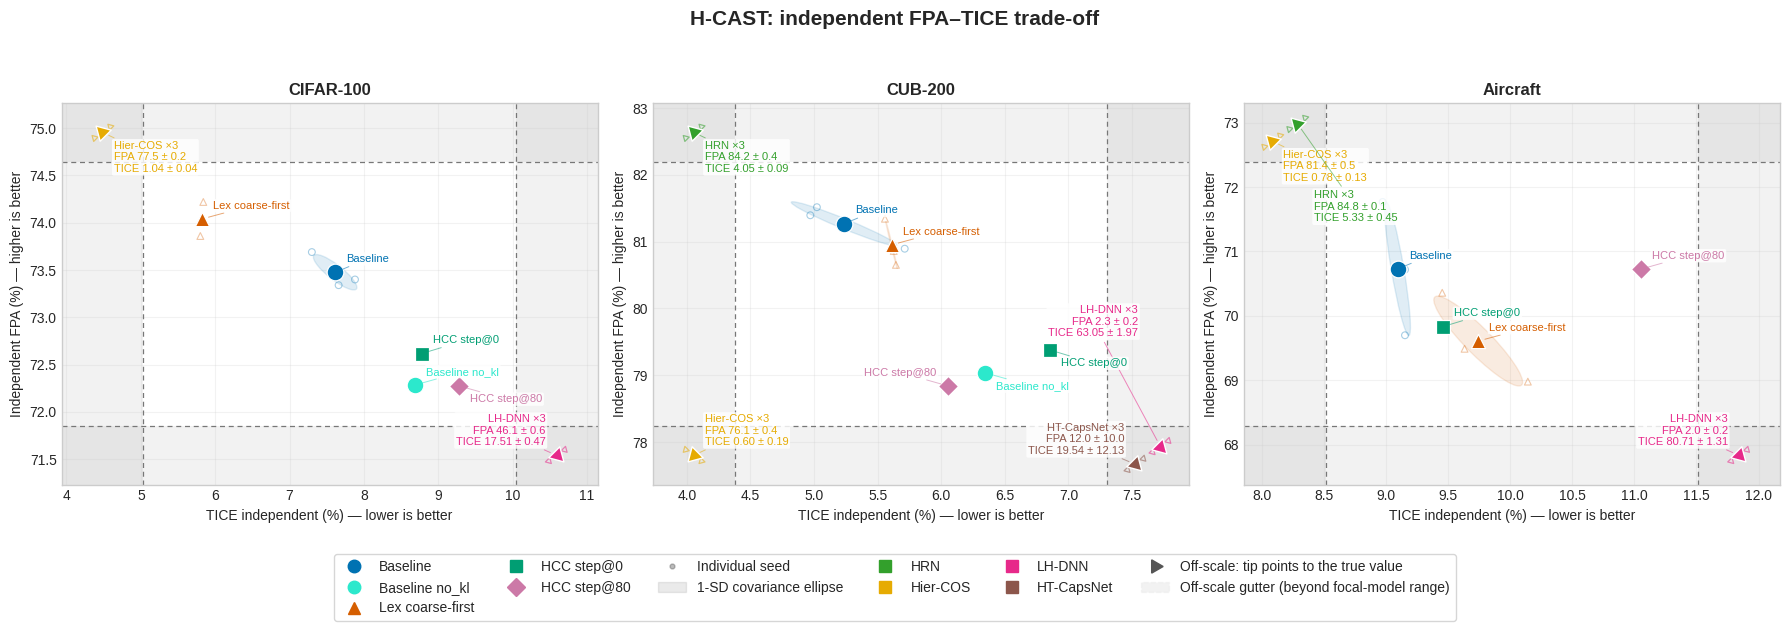

In [8]:
plot_fpa_tice(
    rows, DATASETS, 'H-CAST', FIGURE_DIR, SAVE_FIGURES,
    reference_rows=reference_rows, reference_specs=REFERENCE_SPECS,
)

## Selected-Run Effects Across Hierarchy Levels

Bars are matched-seed changes in independent coarse, middle, and fine accuracy from the native H-CAST baseline. Values are percentage-point deltas. Missing runs and seed pairs are omitted. Because lex disables global KL and Aircraft HCC uses no global KL, those bars should not be interpreted as isolated causal effects of projection or HCC.

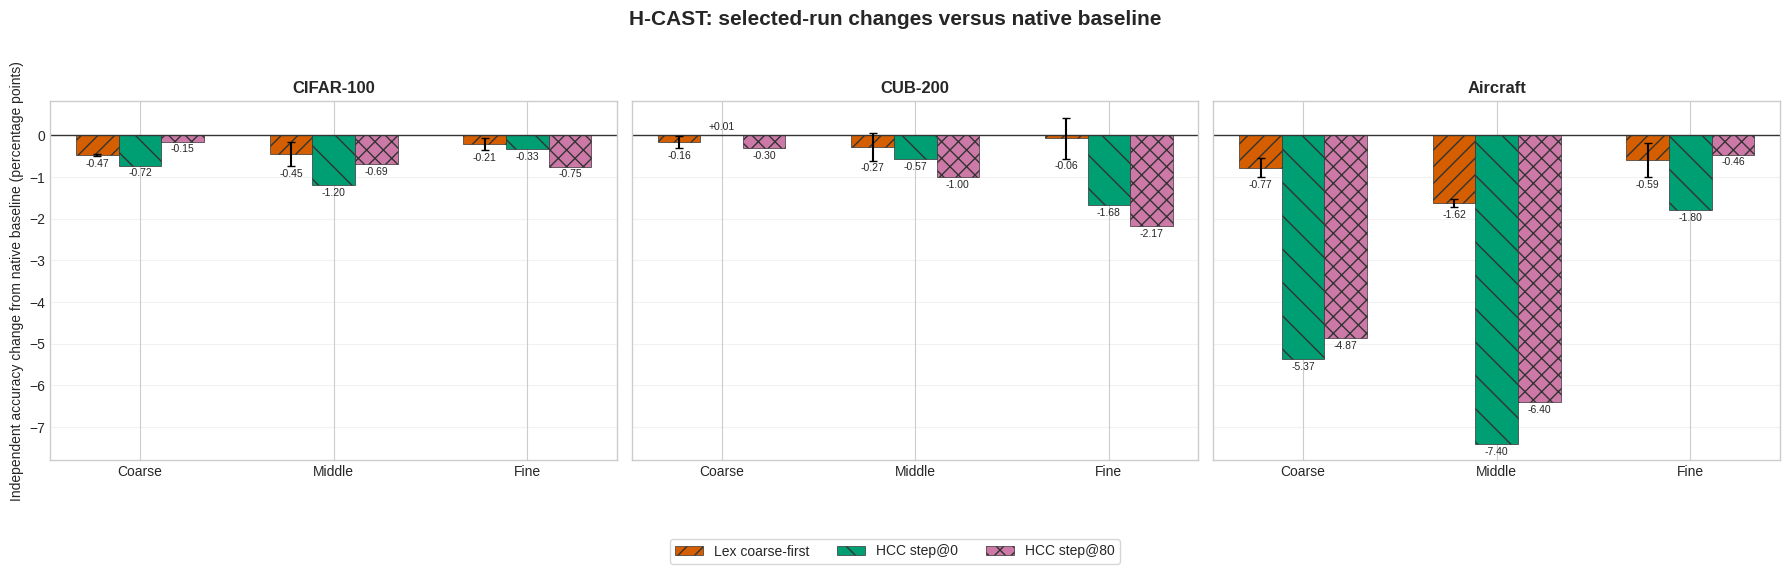

In [9]:
plot_level_accuracy_deltas(rows, DATASETS, 'H-CAST', FIGURE_DIR, SAVE_FIGURES)

## Run and Pareto Summary

A run is Pareto-optimal within a dataset when no available H-CAST run has both higher-or-equal FPA and lower-or-equal TICE, with at least one strict improvement. HCC diagnostics make activation and checkpoint timing explicit.

In [10]:
print_summary(rows, DATASETS)


CIFAR-100
  run                      n   epoch             FPA               TICE              HCC diagnostics          status
  Lex coarse-first          2  98.0 ± 2.8        74.04% ± 0.25     5.82% ± 0.03      —                        Pareto-optimal
  Baseline                  3  97.3 ± 2.3        73.48% ± 0.19     7.61% ± 0.29      —                        dominated by Lex coarse-first
  HCC step@0                1  90                72.62%            8.78%             selected α=1.00; first active=1 dominated by Baseline, Lex coarse-first
  Baseline no_kl            1  93                72.29%            8.69%             —                        dominated by Baseline, Lex coarse-first
  HCC step@80               1  93                72.28%            9.28%             selected α=1.00; first active=81 dominated by Baseline, Baseline no_kl, Lex coarse-first, HCC step@0

CUB-200
  run                      n   epoch             FPA               TICE              HCC diagnostics     